<a href="https://colab.research.google.com/github/atsuro0415/GCI/blob/main/Final_assignment_260614.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Google Driveのマウント
from google.colab import drive
drive.mount('/content/drive')

# モジュールのインポート
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score

!pip install xgboost catboost -q

import lightgbm as lgb

import warnings
warnings.filterwarnings('ignore')

# データの読み込み
PATH = '/content/drive/MyDrive/Colab_Notebooks/GCI/Final_assignment'

HR_Employee_Attrition = pd.read_csv(f'{PATH}/WA_Fn-UseC_-HR-Employee-Attrition.csv', sep=',')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 27.5 MB/s eta 0:00:00


In [2]:
HR_Employee_Attrition.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
# 残業時間の推定

HR_Employee_Attrition['OperatingHours'] = (
    HR_Employee_Attrition['MonthlyIncome'] / HR_Employee_Attrition['HourlyRate']
)

HR_Employee_Attrition['OperatingDays'] = (
    HR_Employee_Attrition['MonthlyIncome'] / HR_Employee_Attrition['DailyRate']
)

HR_Employee_Attrition['OvertimeHours'] = (
    HR_Employee_Attrition['MonthlyIncome'] / HR_Employee_Attrition['HourlyRate']
) - 80

print(HR_Employee_Attrition['OperatingHours'].describe())
print(HR_Employee_Attrition['OperatingDays'].describe())
print(HR_Employee_Attrition['OvertimeHours'].describe())
print()
# マイナスになるケースを確認
print(f"マイナスになる人数: {(HR_Employee_Attrition['OvertimeHours'] < 0).sum()}")

count    1470.000000
mean      110.836100
std        95.245212
min        12.146067
25%        47.334751
50%        78.270321
75%       141.491577
max       620.838710
Name: OperatingHours, dtype: float64
count    1470.000000
mean       12.462828
std        16.428979
min         0.740822
25%         3.903850
50%         7.147781
75%        14.246413
max       185.057143
Name: OperatingDays, dtype: float64
count    1470.000000
mean       30.836100
std        95.245212
min       -67.853933
25%       -32.665249
50%        -1.729679
75%        61.491577
max       540.838710
Name: OvertimeHours, dtype: float64

マイナスになる人数: 753


In [4]:
# 残業時間の推定（マイナスはゼロに丸める）
HR_Employee_Attrition['OvertimeHours'] = (
    HR_Employee_Attrition['MonthlyIncome'] / HR_Employee_Attrition['HourlyRate']
) - 80

HR_Employee_Attrition['OvertimeHours'] = HR_Employee_Attrition['OvertimeHours'].clip(lower=0)

print(HR_Employee_Attrition['OvertimeHours'].describe())
print()

# OverTimeフラグとの整合性確認
print("OverTime=1なのにOvertimeHours=0の人数:",
      ((HR_Employee_Attrition['OverTime'] == 1) &
       (HR_Employee_Attrition['OvertimeHours'] == 0)).sum())

print("OverTime=0なのにOvertimeHours>0の人数:",
      ((HR_Employee_Attrition['OverTime'] == 0) &
       (HR_Employee_Attrition['OvertimeHours'] > 0)).sum())

count    1470.000000
mean       46.967087
std        84.657193
min         0.000000
25%         0.000000
50%         0.000000
75%        61.491577
max       540.838710
Name: OvertimeHours, dtype: float64

OverTime=1なのにOvertimeHours=0の人数: 0
OverTime=0なのにOvertimeHours>0の人数: 0


In [5]:
print(HR_Employee_Attrition.info())
print(HR_Employee_Attrition.isnull().sum())
print(HR_Employee_Attrition.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1470 non-null   int64  
 1   Attrition                 1470 non-null   object 
 2   BusinessTravel            1470 non-null   object 
 3   DailyRate                 1470 non-null   int64  
 4   Department                1470 non-null   object 
 5   DistanceFromHome          1470 non-null   int64  
 6   Education                 1470 non-null   int64  
 7   EducationField            1470 non-null   object 
 8   EmployeeCount             1470 non-null   int64  
 9   EmployeeNumber            1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  JobLevel

In [6]:
#全object列まとめて中身も見たい
for col in HR_Employee_Attrition.select_dtypes(include='object').columns:
    print(f"--- {col} ({HR_Employee_Attrition[col].nunique()}種類) ---")
    print(HR_Employee_Attrition[col].value_counts())
    print()

--- Attrition (2種類) ---
Attrition
No     1233
Yes     237
Name: count, dtype: int64

--- BusinessTravel (3種類) ---
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

--- Department (3種類) ---
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

--- EducationField (6種類) ---
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

--- Gender (2種類) ---
Gender
Male      882
Female    588
Name: count, dtype: int64

--- JobRole (9種類) ---
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources      

In [7]:
# ① 目的変数：Yes/Noの意味を明示してフラグ化
HR_Employee_Attrition['Attrition'] = HR_Employee_Attrition['Attrition'].map({'Yes': 1, 'No': 0})

# ② 不要列の削除（分散ゼロ・IDのみ）
HR_Employee_Attrition = HR_Employee_Attrition.drop(
    columns=['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']
)

# ③ 説明変数：順序なし2値列（Yes/No系）
binary_cols = ['OverTime']
for col in binary_cols:
   HR_Employee_Attrition[col] = LabelEncoder().fit_transform(HR_Employee_Attrition[col])

# ④ 説明変数：順序なし多値列（ダミー変数化）
HR_Employee_Attrition['AgeGroup'] = pd.cut(
    HR_Employee_Attrition['Age'],
    bins=[0, 35, 45, 99],
    labels=['young', 'middle', 'senior']
)

HR_Employee_Attrition['AgeGroup_raw'] = pd.cut(
    HR_Employee_Attrition['Age'],
    bins=[0, 35, 45, 99],
    labels=['young(~35)', 'middle(36-45)', 'senior(46+)']
)


# ダミー化しないHR_Employee_Attrition_raw作成
HR_Employee_Attrition_raw = HR_Employee_Attrition.copy()



# get_dummies
nominal_cols = ['BusinessTravel', 'Department', 'EducationField',
                'JobRole', 'MaritalStatus', 'AgeGroup']
HR_Employee_Attrition = pd.get_dummies(HR_Employee_Attrition, columns=nominal_cols, drop_first=True)


#残業時間
HR_Employee_Attrition['OvertimeHours'] = (
    HR_Employee_Attrition['MonthlyIncome'] / HR_Employee_Attrition['HourlyRate'] - 80
).clip(lower=0)

# OverTimeは削除
HR_Employee_Attrition = HR_Employee_Attrition.drop(columns=['OverTime'])

# 男女別に分割
df_male = HR_Employee_Attrition[HR_Employee_Attrition['Gender'] == 'Male']
df_female = HR_Employee_Attrition[HR_Employee_Attrition['Gender'] == 'Female']
print(f"男性: {len(df_male)}人")
print(f"女性: {len(df_female)}人")

df_male_raw = HR_Employee_Attrition_raw[HR_Employee_Attrition_raw['Gender'] == 'Male']
df_female_raw = HR_Employee_Attrition_raw[HR_Employee_Attrition_raw['Gender'] == 'Female']

# ⑤ 説明変数：順序なし2値列（Yes/No系）
binary_cols = ['Gender']
for col in binary_cols:
    df_male[col] = LabelEncoder().fit_transform(df_male[col])
    df_female[col] = LabelEncoder().fit_transform(df_female[col])

# ⑥離職者のみに着目
binary_cols = ['Attrition']
df_male_attrition = df_male[df_male['Attrition'] == 1]
df_female_attrition = df_female[df_female['Attrition'] == 1]


print(df_male.shape)
print(df_female.shape)
print(df_male.dtypes)
print(df_female.dtypes)
print(df_male.head())
print(df_female.head())
print(df_male_attrition.head())
print(df_female_attrition.head())


男性: 882人
女性: 588人
(882, 50)
(588, 50)
Age                                     int64
Attrition                               int64
DailyRate                               int64
DistanceFromHome                        int64
Education                               int64
EnvironmentSatisfaction                 int64
Gender                                  int64
HourlyRate                              int64
JobInvolvement                          int64
JobLevel                                int64
JobSatisfaction                         int64
MonthlyIncome                           int64
MonthlyRate                             int64
NumCompaniesWorked                      int64
PercentSalaryHike                       int64
PerformanceRating                       int64
RelationshipSatisfaction                int64
StockOptionLevel                        int64
TotalWorkingYears                       int64
TrainingTimesLastYear                   int64
WorkLifeBalance                         in

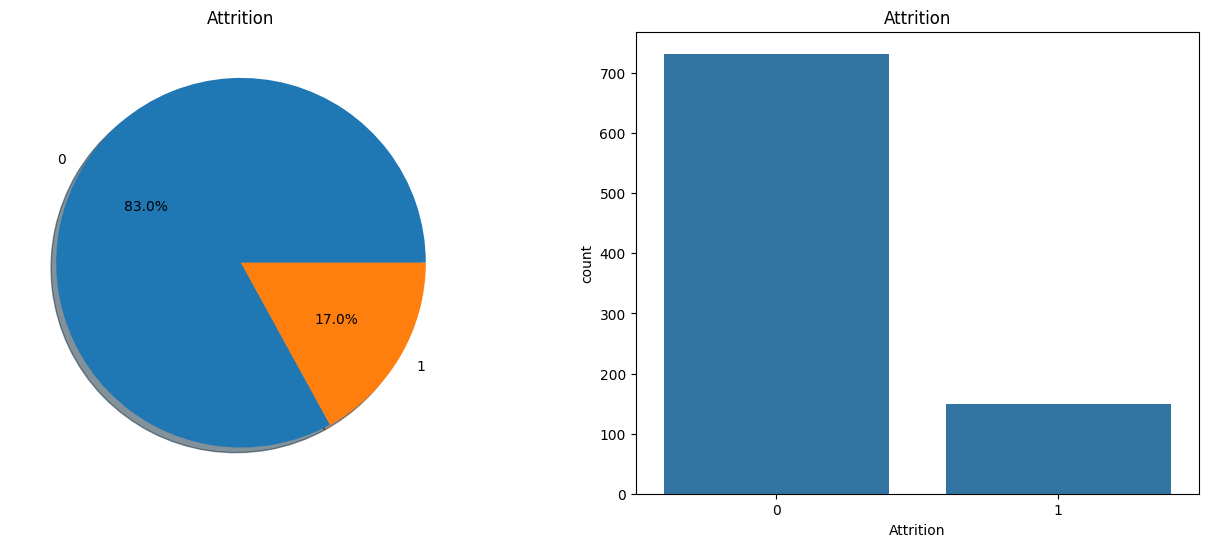

In [8]:
#男性の離職率
f, ax = plt.subplots(1, 2, figsize=(16, 6))
df_male['Attrition'].value_counts().plot.pie(autopct='%1.1f%%', ax=ax[0], shadow=True)
ax[0].set_title('Attrition')
ax[0].set_ylabel('')
sns.countplot(x='Attrition', data=df_male, ax=ax[1])
ax[1].set_title('Attrition')
plt.show()

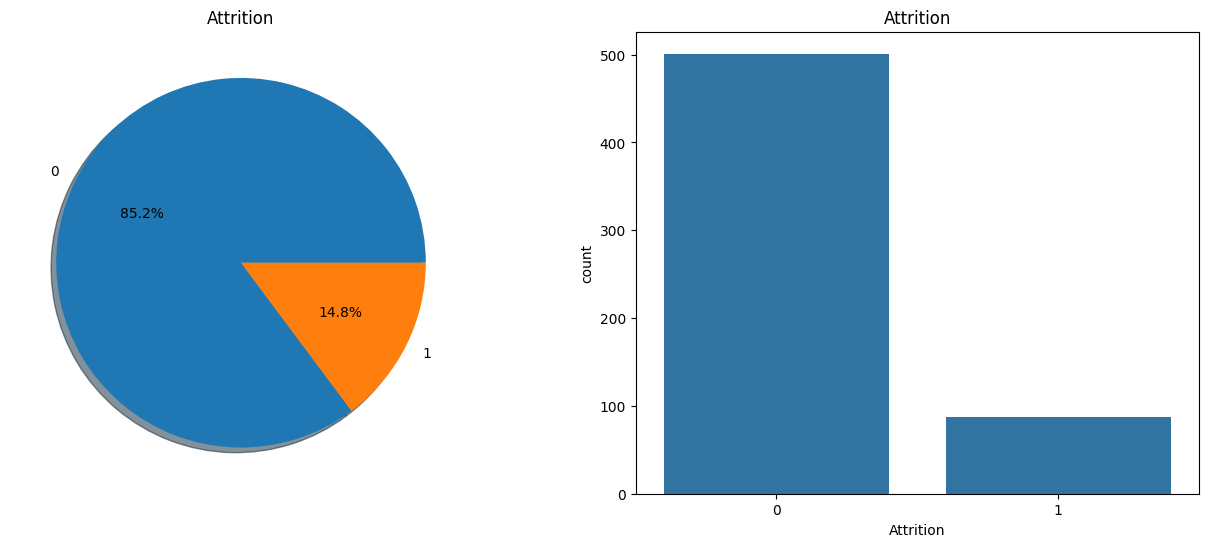

In [9]:
#女性の離職率
f, ax = plt.subplots(1, 2, figsize=(16, 6))
df_female['Attrition'].value_counts().plot.pie(autopct='%1.1f%%', ax=ax[0], shadow=True)
ax[0].set_title('Attrition')
ax[0].set_ylabel('')
sns.countplot(x='Attrition', data=df_female, ax=ax[1])
ax[1].set_title('Attrition')
plt.show()

In [10]:
# matplotlib日本語化モジュールをまず実行環境にインストールする。
!pip install -q japanize-matplotlib
import japanize_matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 117.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


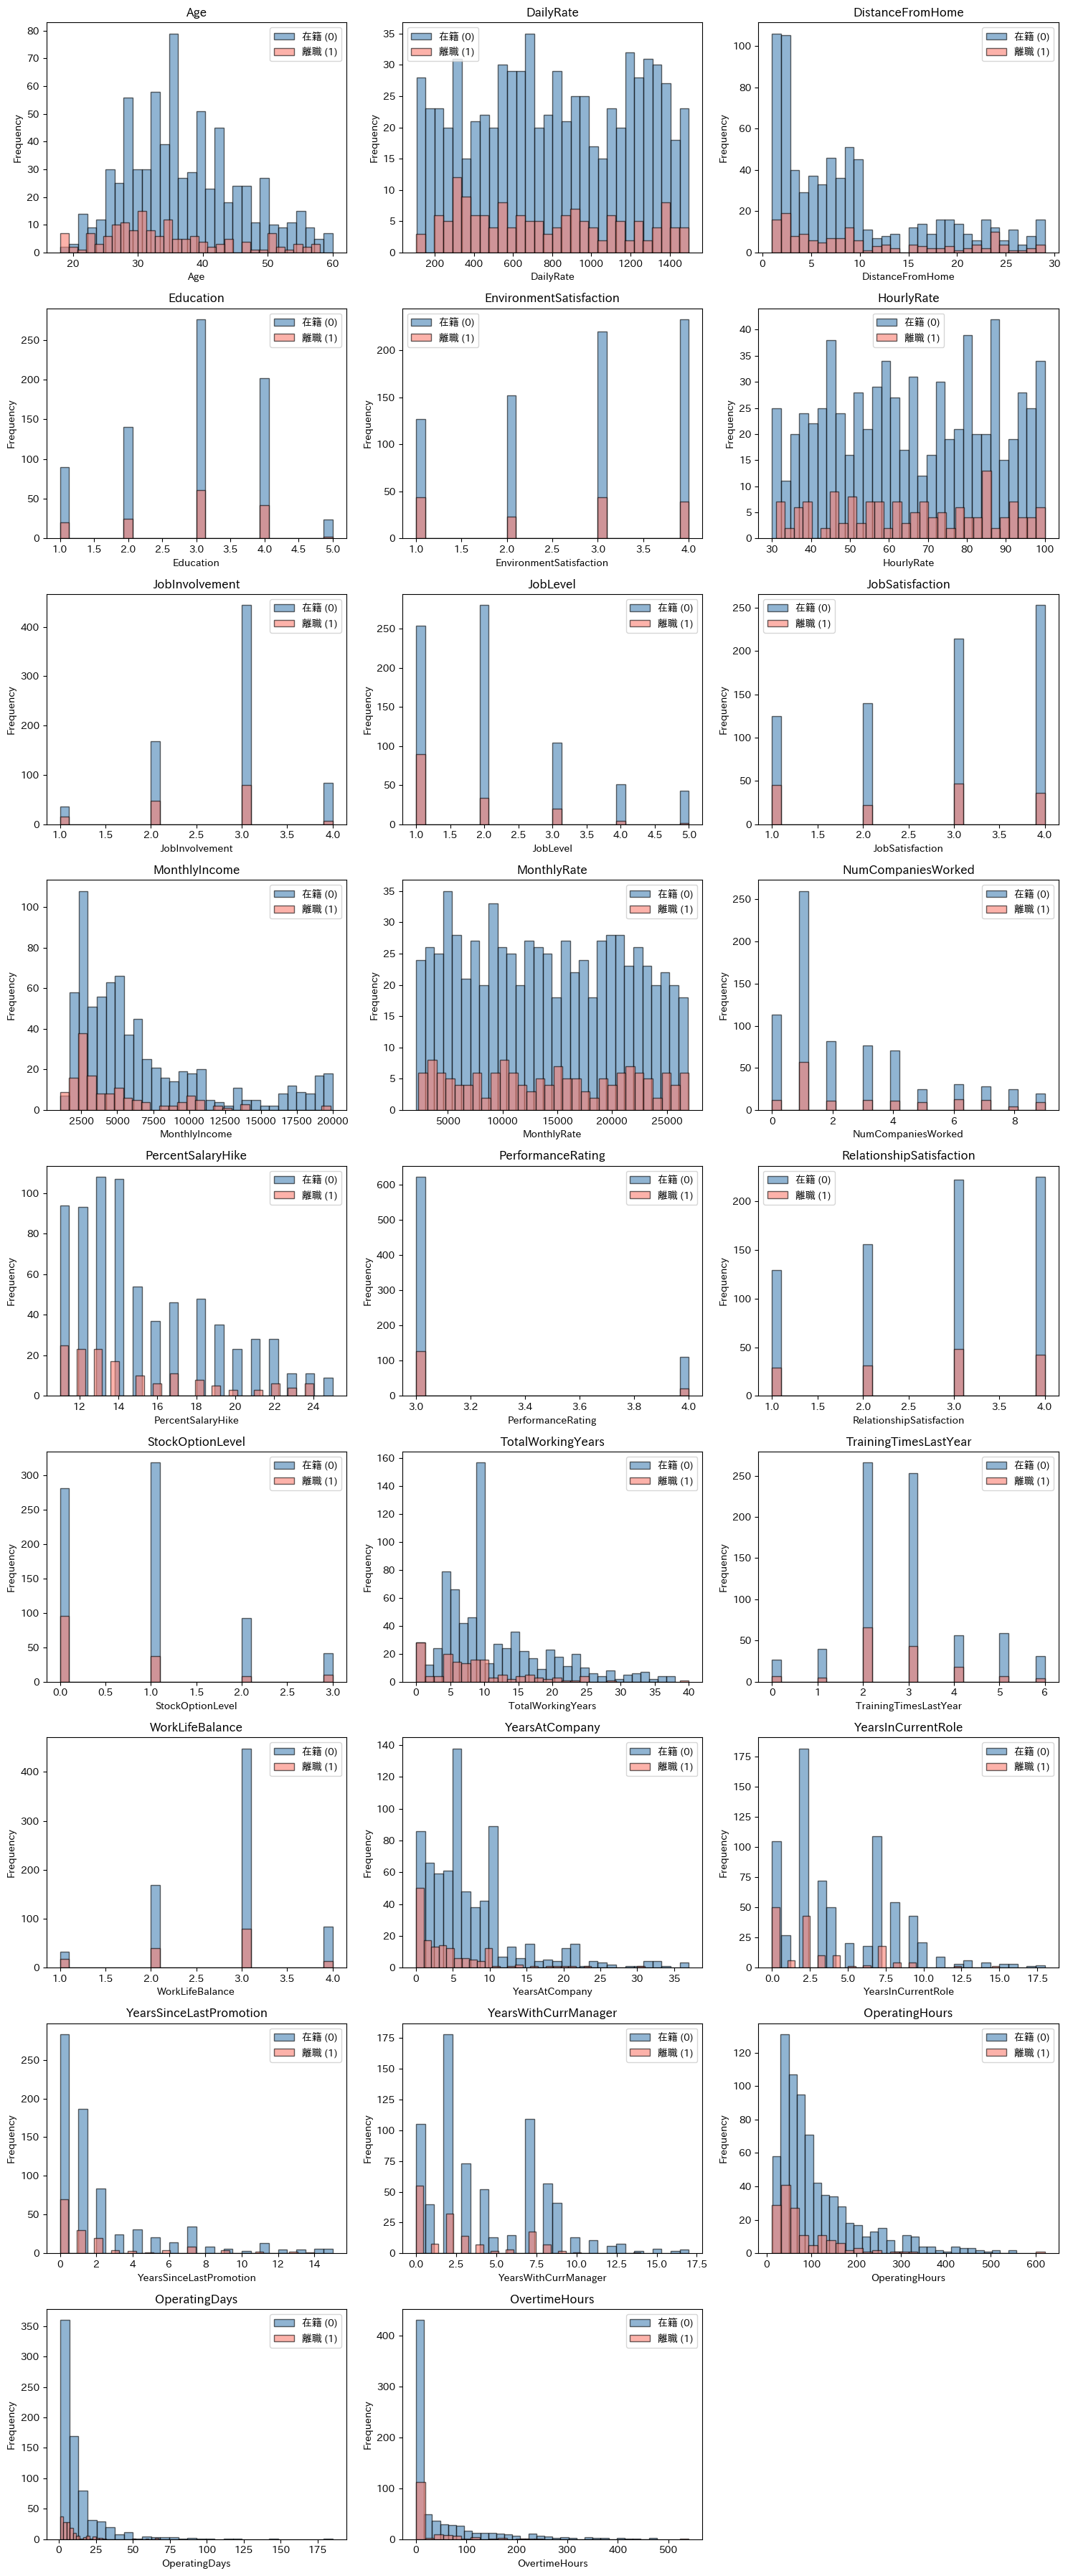

In [11]:
numeric_cols = df_male.select_dtypes(include=['number']).columns.drop(['Gender', 'Attrition'])

cols = 3
rows = (len(numeric_cols) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]

    # Attrition=0（在籍）とAttrition=1（離職）を重ねて描画
    ax.hist(df_male[df_male['Attrition'] == 0][col].dropna(),
            bins=30, alpha=0.6, label='在籍 (0)', color='steelblue', edgecolor='black')
    ax.hist(df_male[df_male['Attrition'] == 1][col].dropna(),
            bins=30, alpha=0.6, label='離職 (1)', color='salmon', edgecolor='black')

    ax.set_title(f'{col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.legend()

# 余ったサブプロットを非表示
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

#import seaborn as sns
#import matplotlib.pyplot as plt

#sns.pairplot(df_male)
#plt.show()

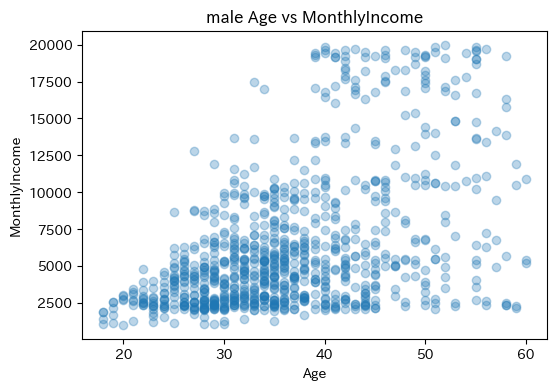

In [12]:
# alcohol と quality だけ取り出して散布図
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.scatter(df_male['Age'],
            df_male['MonthlyIncome'], #+ np.random.uniform(-0.2, 0.2, len(df_male)),  # jitter
            alpha=0.3)
#alpha=0.3（透明度）と jitter（縦方向にランダムにずらす）を加えることで、重なりが解消されて傾向が見えやすくなります。
plt.xlabel('Age')
plt.ylabel('MonthlyIncome')
plt.title('male Age vs MonthlyIncome')
plt.show()

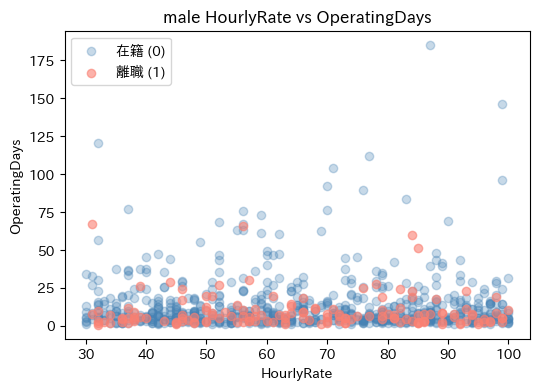

In [13]:
plt.figure(figsize=(6, 4))

# 在籍者（Attrition=0）
plt.scatter(df_male[df_male['Attrition'] == 0]['HourlyRate'],
            df_male[df_male['Attrition'] == 0]['OperatingDays'],
            alpha=0.3, color='steelblue', label='在籍 (0)')

# 離職者（Attrition=1）
plt.scatter(df_male[df_male['Attrition'] == 1]['HourlyRate'],
            df_male[df_male['Attrition'] == 1]['OperatingDays'],
            alpha=0.6, color='salmon', label='離職 (1)')

plt.xlabel('HourlyRate')
plt.ylabel('OperatingDays')
plt.title('male HourlyRate vs OperatingDays')
plt.legend()
plt.show()

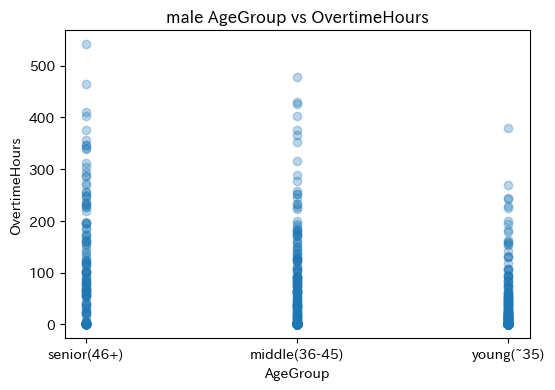

In [14]:
#男性 2軸散布図
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
age_group = pd.cut(df_male['Age'], bins=[0, 35, 45, 99],
                   labels=['young(~35)', 'middle(36-45)', 'senior(46+)'])
plt.scatter(age_group,
            df_male['OvertimeHours'] + np.random.uniform(-0.2, 0.2, len(df_male)),
            alpha=0.3)
plt.xlabel('AgeGroup')
plt.ylabel('OvertimeHours')
plt.title('male AgeGroup vs OvertimeHours')
plt.show()

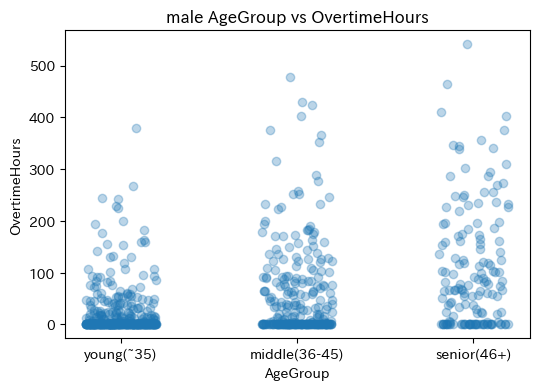

In [15]:
import matplotlib.pyplot as plt
import numpy as np

age_group = pd.cut(df_male['Age'], bins=[0, 35, 45, 99],
                   labels=['young(~35)', 'middle(36-45)', 'senior(46+)'])

age_map = {'young(~35)': 0, 'middle(36-45)': 1, 'senior(46+)': 2}
age_numeric = age_group.map(age_map).astype(float)  # ← astype(float)を追加

plt.figure(figsize=(6, 4))
plt.scatter(
    age_numeric + np.random.uniform(-0.2, 0.2, len(df_male)),
    df_male['OvertimeHours'],
    alpha=0.3
)

plt.xticks([0, 1, 2], ['young(~35)', 'middle(36-45)', 'senior(46+)'])
plt.xlabel('AgeGroup')
plt.ylabel('OvertimeHours')
plt.title('male AgeGroup vs OvertimeHours')
plt.show()

In [16]:
# JobRole関連の列を確認
print([col for col in df_male_raw.columns if 'JobRole' in col])

['JobRole']


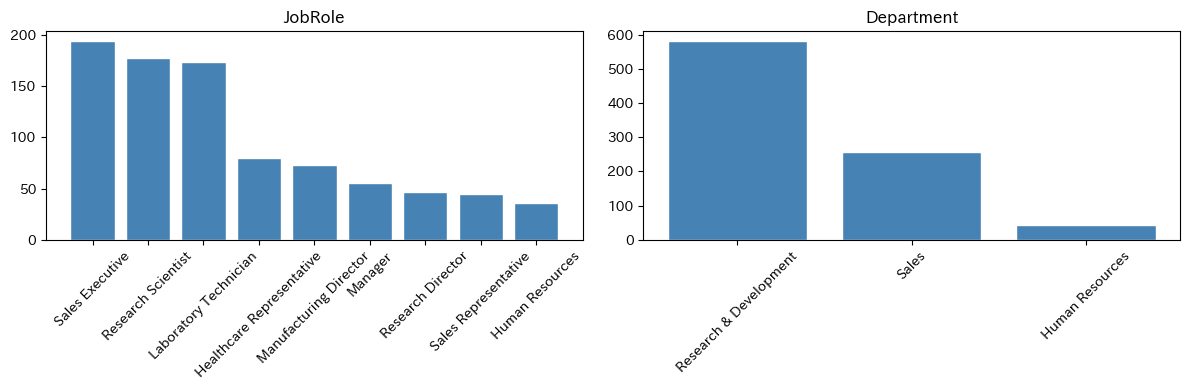

In [17]:
categorical_cols = ['JobRole','Department']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, col in enumerate(categorical_cols):
    counts = df_male_raw[col].value_counts()
    axes[i].bar(counts.index, counts.values, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()



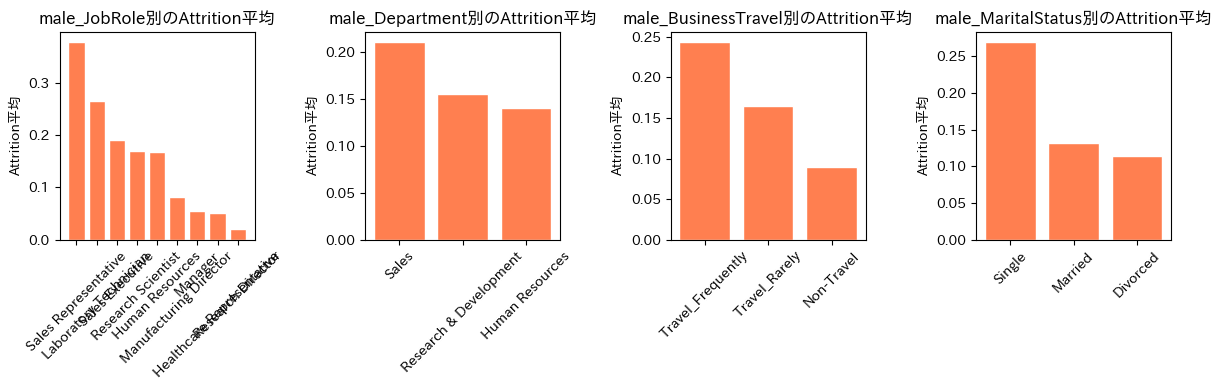

In [18]:
categorical_cols = ['JobRole','Department','BusinessTravel','MaritalStatus']

fig, axes = plt.subplots(1, 4, figsize=(12, 4))
for i, col in enumerate(categorical_cols):
    Attrition_mean = df_male_raw.groupby(col)['Attrition'].mean().sort_values(ascending=False)
    axes[i].bar(Attrition_mean.index, Attrition_mean.values, color='coral', edgecolor='white')
    axes[i].set_title(f'male_{col}別のAttrition平均')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('Attrition平均')
plt.tight_layout()
plt.show()


=== 男性 ===
若手SalesRep (n=19): 平均=0.58, 中央値=0.0
それ以外    (n=863):  平均=0.81, 中央値=1.0


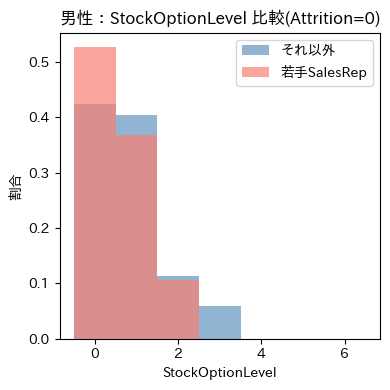


=== 女性 ===
若手SalesRep (n=18): 平均=0.94, 中央値=1.0
それ以外    (n=570):  平均=0.78, 中央値=1.0


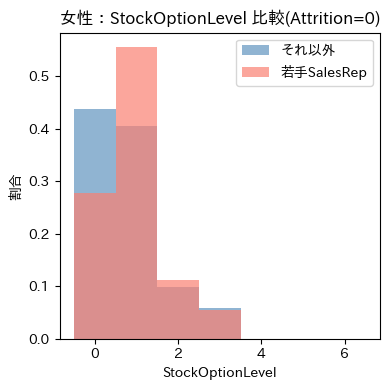

In [36]:
for label, df_raw in [('男性', df_male_raw), ('女性', df_female_raw)]:
    # 条件に合うグループ
    mask = (df_raw['AgeGroup_raw'] == 'young(~35)') & (df_raw['JobRole'] == 'Sales Representative') & (df_raw['Attrition'] == 0)

    group_target = df_raw[mask]['StockOptionLevel']
    group_other  = df_raw[~mask]['StockOptionLevel']

    print(f"\n=== {label} ===")
    print(f"若手SalesRep (n={len(group_target)}): 平均={group_target.mean():.2f}, 中央値={group_target.median():.1f}")
    print(f"それ以外    (n={len(group_other)}):  平均={group_other.mean():.2f}, 中央値={group_other.median():.1f}")

    # 可視化
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.hist(group_other,  bins=range(0, 8), alpha=0.6, color='steelblue', label='それ以外',     density=True, align='left')
    ax.hist(group_target, bins=range(0, 8), alpha=0.7, color='salmon',    label='若手SalesRep', density=True, align='left')
    ax.set_title(f'{label}：StockOptionLevel 比較(Attrition=0)')
    ax.set_xlabel('StockOptionLevel')
    ax.set_ylabel('割合')
    ax.legend()
    plt.tight_layout()
    plt.show()


=== 男性 ===
若手SalesRep (n=19): 平均=0.58, 中央値=0.0
若手SalesRep_Attrition (n=14):  平均=0.57, 中央値=0.0


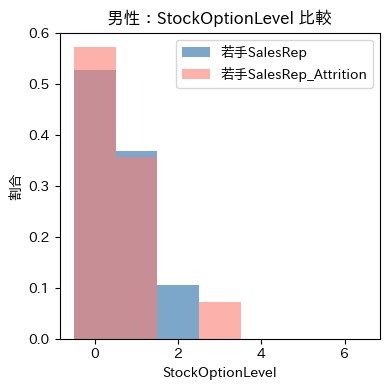


=== 女性 ===
若手SalesRep (n=18): 平均=0.94, 中央値=1.0
若手SalesRep_Attrition (n=14):  平均=0.29, 中央値=0.0


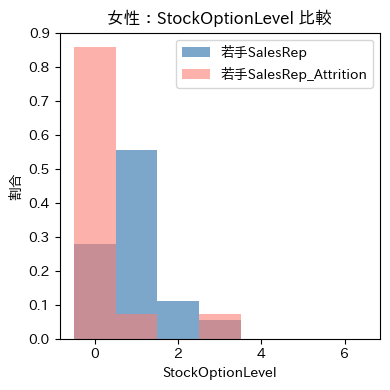

In [37]:
for label, df_raw in [('男性', df_male_raw), ('女性', df_female_raw)]:
    # 条件に合うグループ
    mask = (df_raw['AgeGroup_raw'] == 'young(~35)') & (df_raw['JobRole'] =='Sales Representative') & (df_raw['Attrition'] == 0)
    mask_Attrition = (df_raw['AgeGroup_raw'] == 'young(~35)') & (df_raw['JobRole'] == 'Sales Representative') & (df_raw['Attrition'] == 1)

    group_target = df_raw[mask]['StockOptionLevel']
    group_Attrition  = df_raw[mask_Attrition]['StockOptionLevel']

    print(f"\n=== {label} ===")
    print(f"若手SalesRep (n={len(group_target)}): 平均={group_target.mean():.2f}, 中央値={group_target.median():.1f}")
    print(f"若手SalesRep_Attrition (n={len(group_Attrition)}):  平均={group_Attrition.mean():.2f}, 中央値={group_Attrition.median():.1f}")

    # 可視化
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.hist(group_target, bins=range(0, 8), alpha=0.7, color='steelblue',    label='若手SalesRep', density=True, align='left')
    ax.hist(group_Attrition,  bins=range(0, 8), alpha=0.6, color='salmon', label='若手SalesRep_Attrition',     density=True, align='left')
    ax.set_title(f'{label}：StockOptionLevel 比較')
    ax.set_xlabel('StockOptionLevel')
    ax.set_ylabel('割合')
    ax.legend()
    plt.tight_layout()
    plt.show()

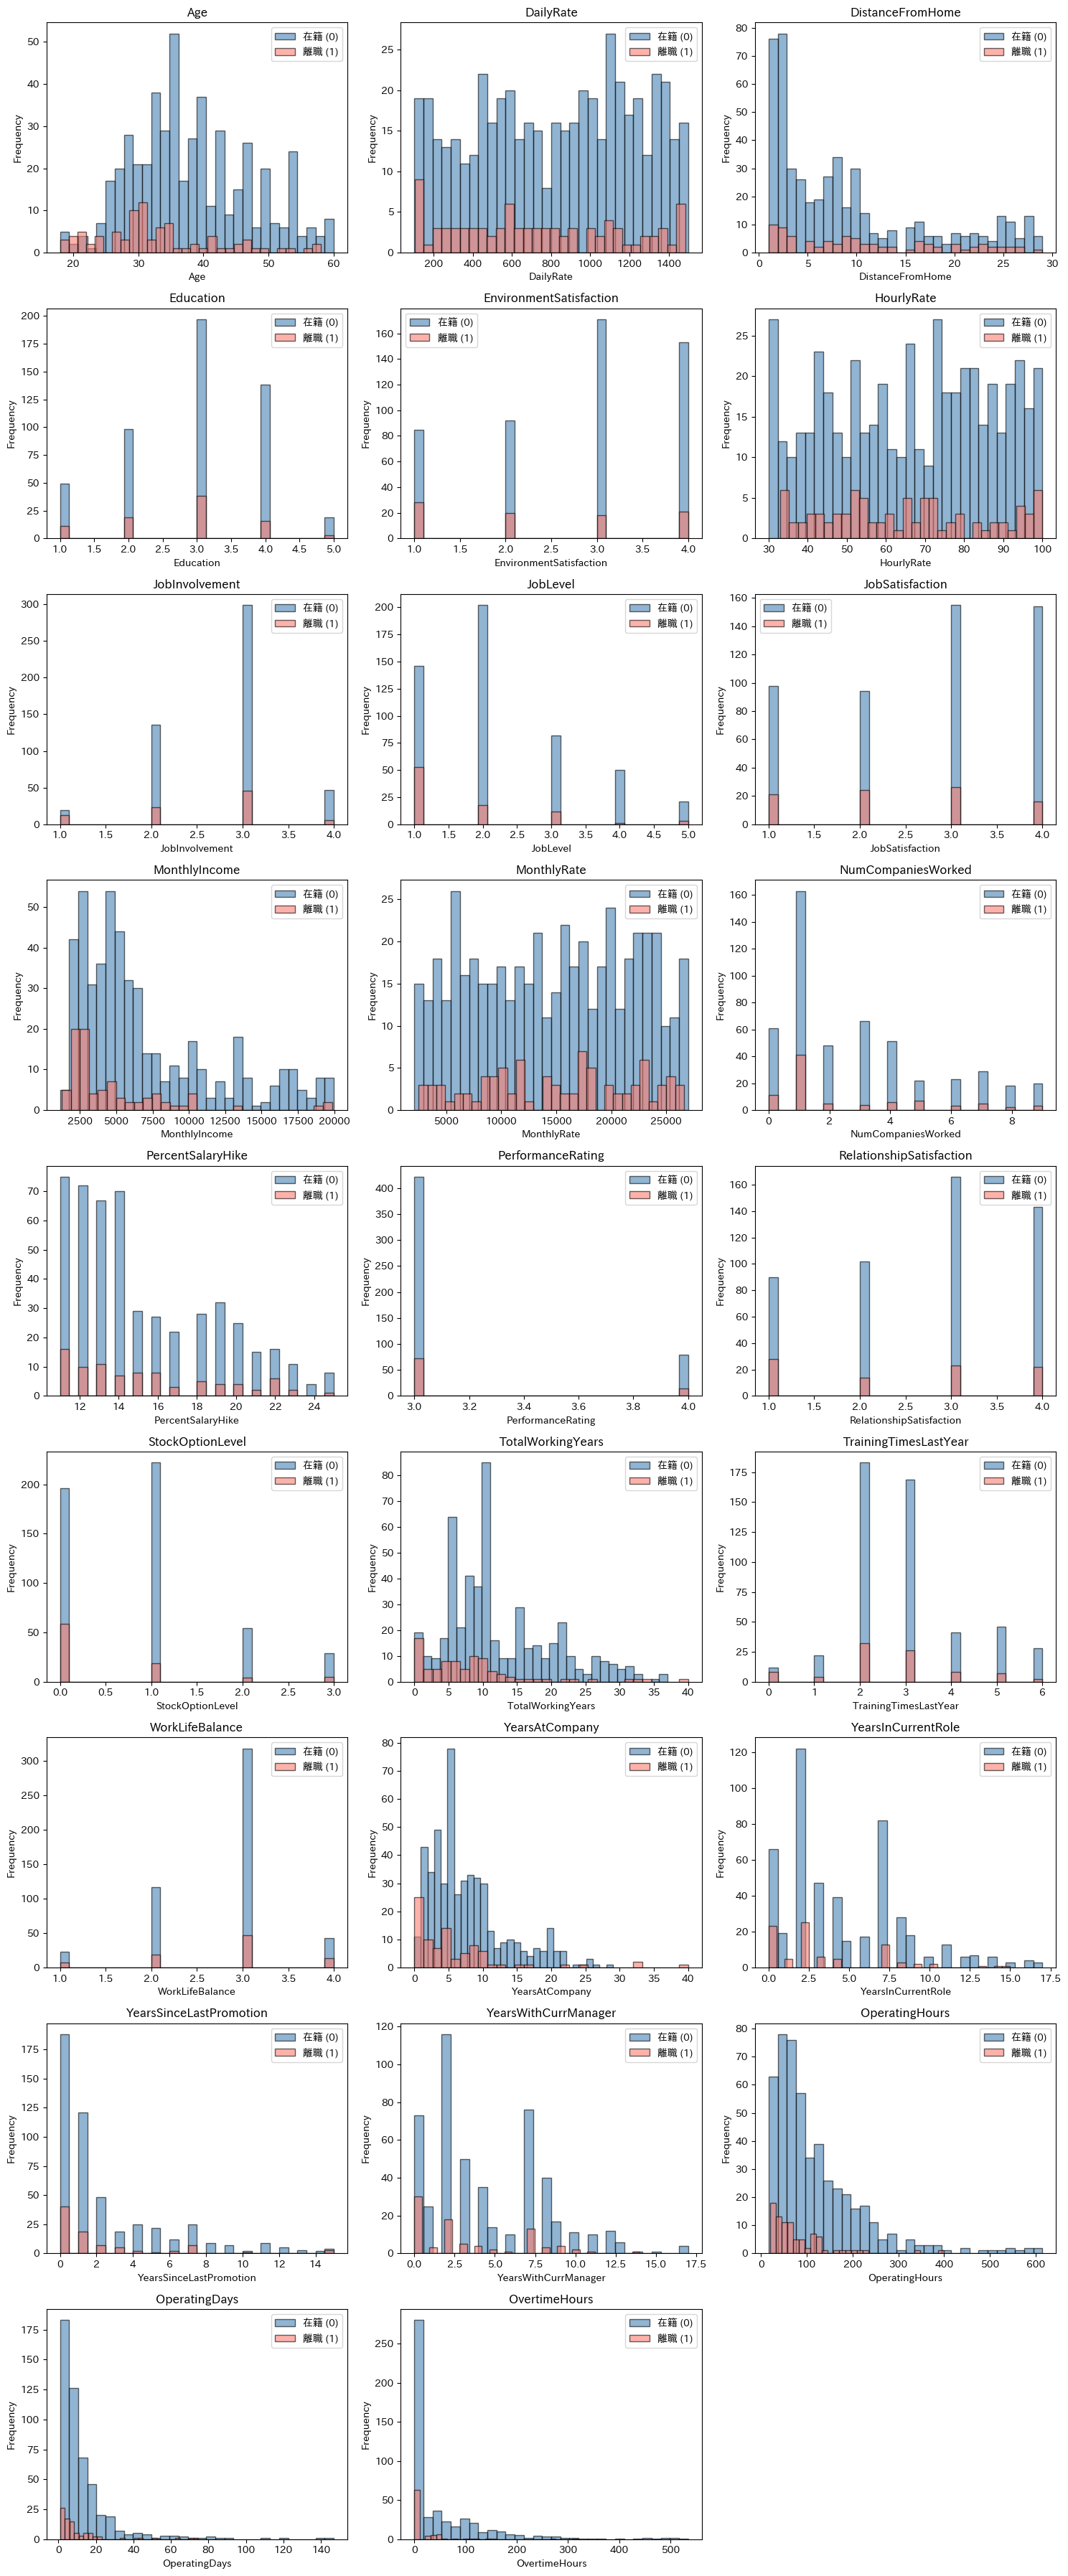

In [23]:
numeric_cols = df_female.select_dtypes(include=['number']).columns.drop(['Gender', 'Attrition'])

cols = 3
rows = (len(numeric_cols) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]

    # Attrition=0（在籍）とAttrition=1（離職）を重ねて描画
    ax.hist(df_female[df_female['Attrition'] == 0][col].dropna(),
            bins=30, alpha=0.6, label='在籍 (0)', color='steelblue', edgecolor='black')
    ax.hist(df_female[df_female['Attrition'] == 1][col].dropna(),
            bins=30, alpha=0.6, label='離職 (1)', color='salmon', edgecolor='black')

    ax.set_title(f'{col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.legend()

# 余ったサブプロットを非表示
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

#import seaborn as sns
#import matplotlib.pyplot as plt

#sns.pairplot(df_female)
#plt.show()


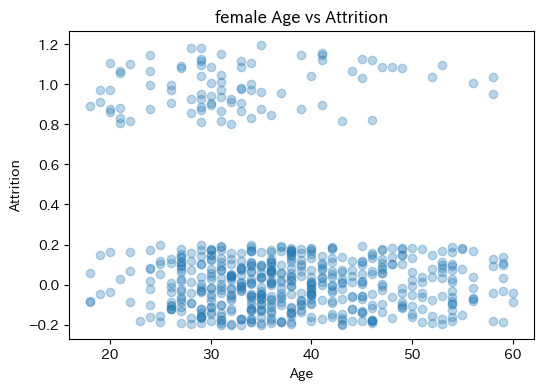

In [23]:
#女性 2軸散布図
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.scatter(df_female['Age'],
             df_female['Attrition'] + np.random.uniform(-0.2, 0.2, len( df_female)),  # jitter
            alpha=0.3)
#alpha=0.3（透明度）と jitter（縦方向にランダムにずらす）を加えることで、重なりが解消されて傾向が見えやすくなります。
plt.xlabel('Age')
plt.ylabel('Attrition')
plt.title('female Age vs Attrition')
plt.show()

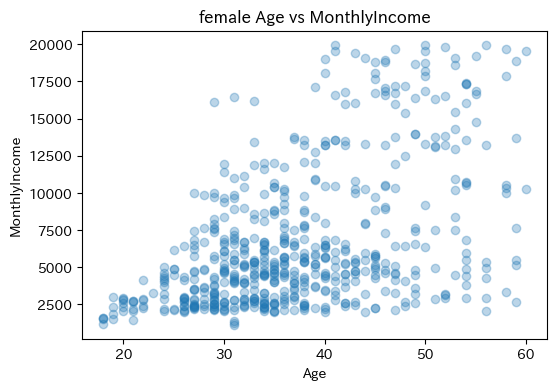

In [24]:
# alcohol と quality だけ取り出して散布図
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.scatter(df_female['Age'],
            df_female['MonthlyIncome'], #+ np.random.uniform(-0.2, 0.2, len(df_female)),  # jitter
            alpha=0.3)
#alpha=0.3（透明度）と jitter（縦方向にランダムにずらす）を加えることで、重なりが解消されて傾向が見えやすくなります。
plt.xlabel('Age')
plt.ylabel('MonthlyIncome')
plt.title('female Age vs MonthlyIncome')
plt.show()

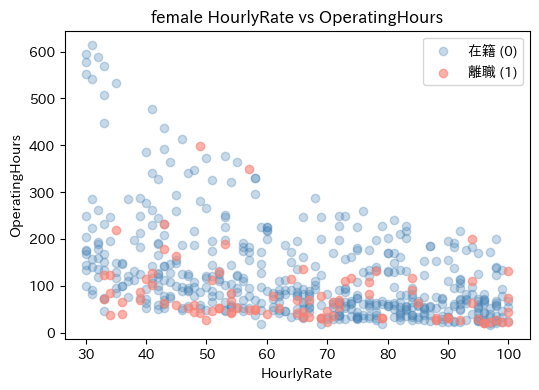

In [25]:
plt.figure(figsize=(6, 4))

# 在籍者（Attrition=0）
plt.scatter(df_female[df_female['Attrition'] == 0]['HourlyRate'],
            df_female[df_female['Attrition'] == 0]['OperatingHours'],
            alpha=0.3, color='steelblue', label='在籍 (0)')

# 離職者（Attrition=1）
plt.scatter(df_female[df_female['Attrition'] == 1]['HourlyRate'],
            df_female[df_female['Attrition'] == 1]['OperatingHours'],
            alpha=0.6, color='salmon', label='離職 (1)')

plt.xlabel('HourlyRate')
plt.ylabel('OperatingHours')
plt.title('female HourlyRate vs OperatingHours')
plt.legend()
plt.show()

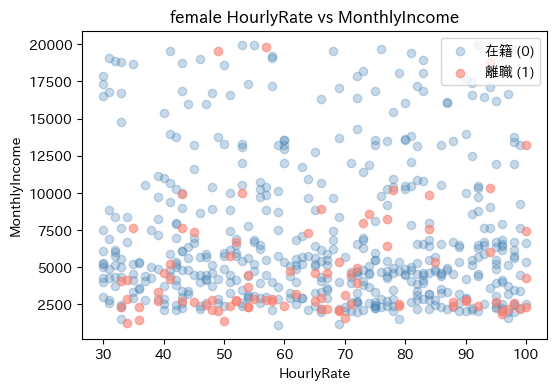

In [26]:
plt.figure(figsize=(6, 4))

# 在籍者（Attrition=0）
plt.scatter(df_female[df_female['Attrition'] == 0]['HourlyRate'],
            df_female[df_female['Attrition'] == 0]['MonthlyIncome'],
            alpha=0.3, color='steelblue', label='在籍 (0)')

# 離職者（Attrition=1）
plt.scatter(df_female[df_female['Attrition'] == 1]['HourlyRate'],
            df_female[df_female['Attrition'] == 1]['MonthlyIncome'],
            alpha=0.6, color='salmon', label='離職 (1)')

plt.xlabel('HourlyRate')
plt.ylabel('MonthlyIncome')
plt.title('female HourlyRate vs MonthlyIncome')
plt.legend()
plt.show()

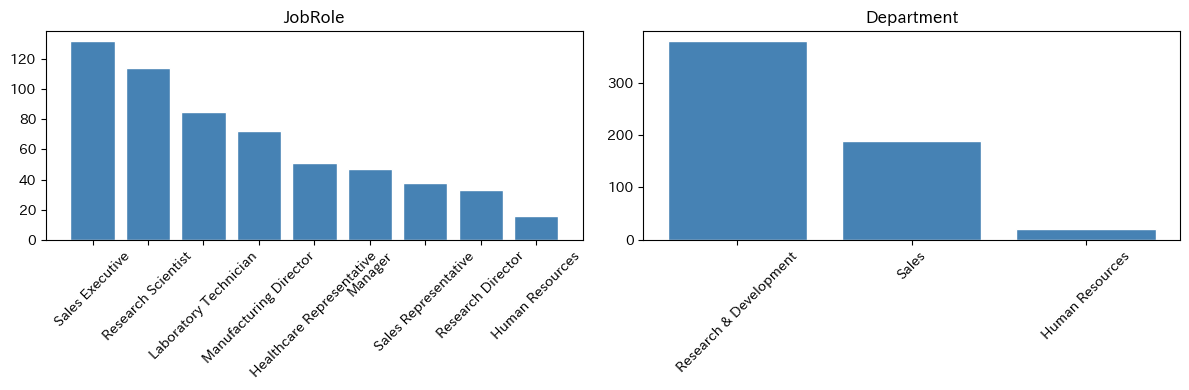

In [36]:
categorical_cols = ['JobRole','Department']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, col in enumerate(categorical_cols):
    counts = df_female_raw[col].value_counts()
    axes[i].bar(counts.index, counts.values, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

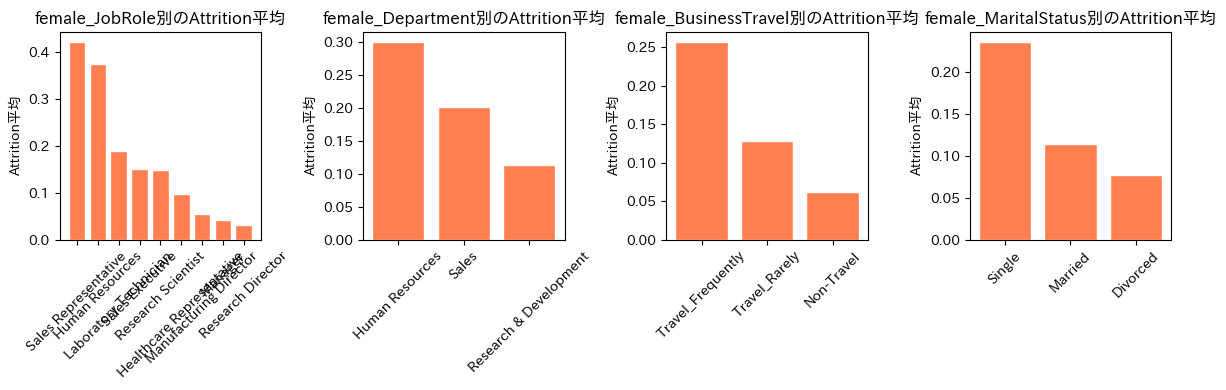

In [44]:
categorical_cols = ['JobRole','Department','BusinessTravel','MaritalStatus']

fig, axes = plt.subplots(1, 4, figsize=(12, 4))
for i, col in enumerate(categorical_cols):
    Attrition_mean = df_female_raw.groupby(col)['Attrition'].mean().sort_values(ascending=False)
    axes[i].bar(Attrition_mean.index, Attrition_mean.values, color='coral', edgecolor='white')
    axes[i].set_title(f'female_{col}別のAttrition平均')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('Attrition平均')
plt.tight_layout()
plt.show()

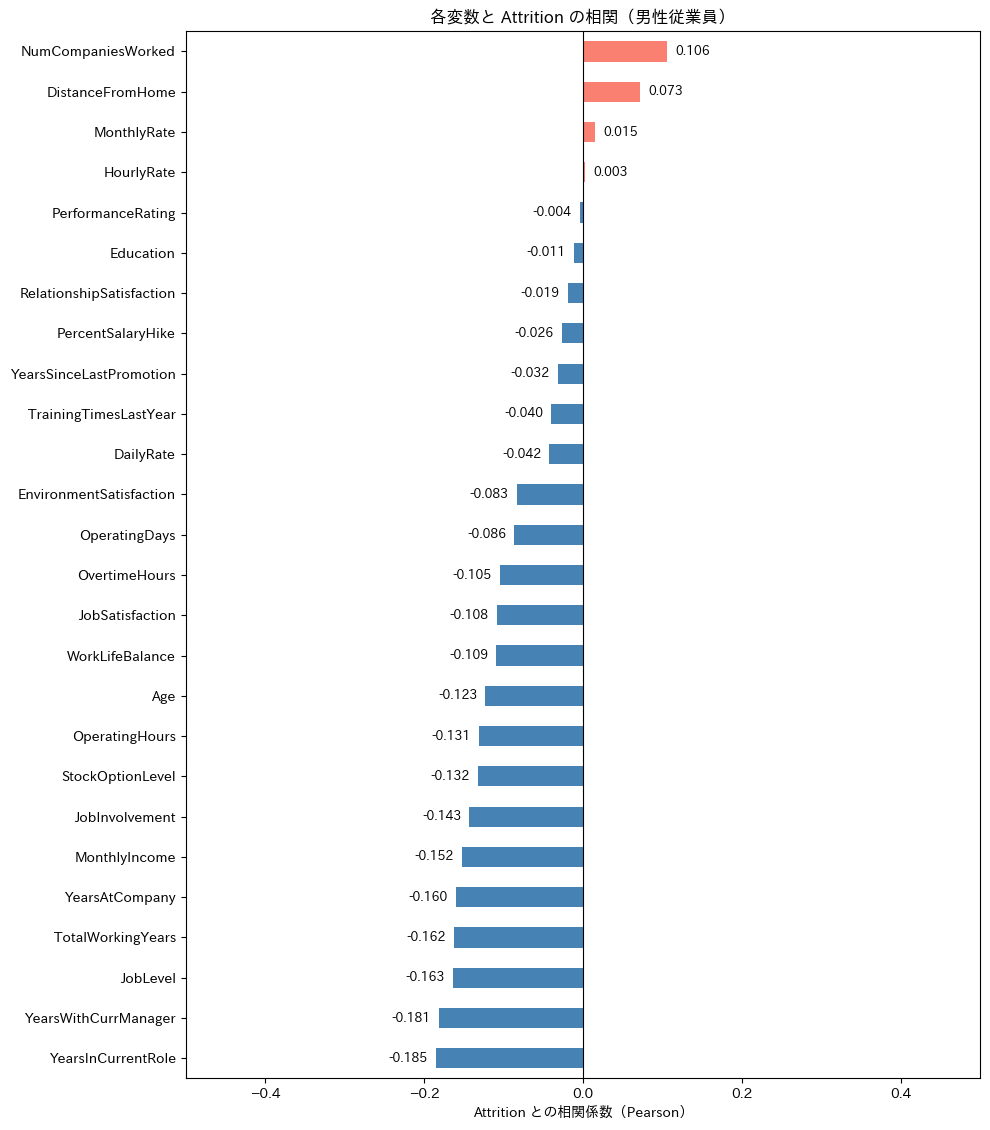

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Attritionとの相関係数を計算
corr = df_male[numeric_cols].corrwith(df_male['Attrition']).sort_values()

# 水平棒グラフで可視化
fig, ax = plt.subplots(figsize=(10, len(numeric_cols) * 0.4 + 1))

colors = ['salmon' if v > 0 else 'steelblue' for v in corr]
corr.plot(kind='barh', ax=ax, color=colors)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Attrition との相関係数（Pearson）')
ax.set_title('各変数と Attrition の相関（男性従業員）')
ax.set_xlim(-0.5, 0.5)

for i, (val, name) in enumerate(zip(corr.values, corr.index)):
    ax.text(val + (0.01 if val >= 0 else -0.01), i,
            f'{val:.3f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

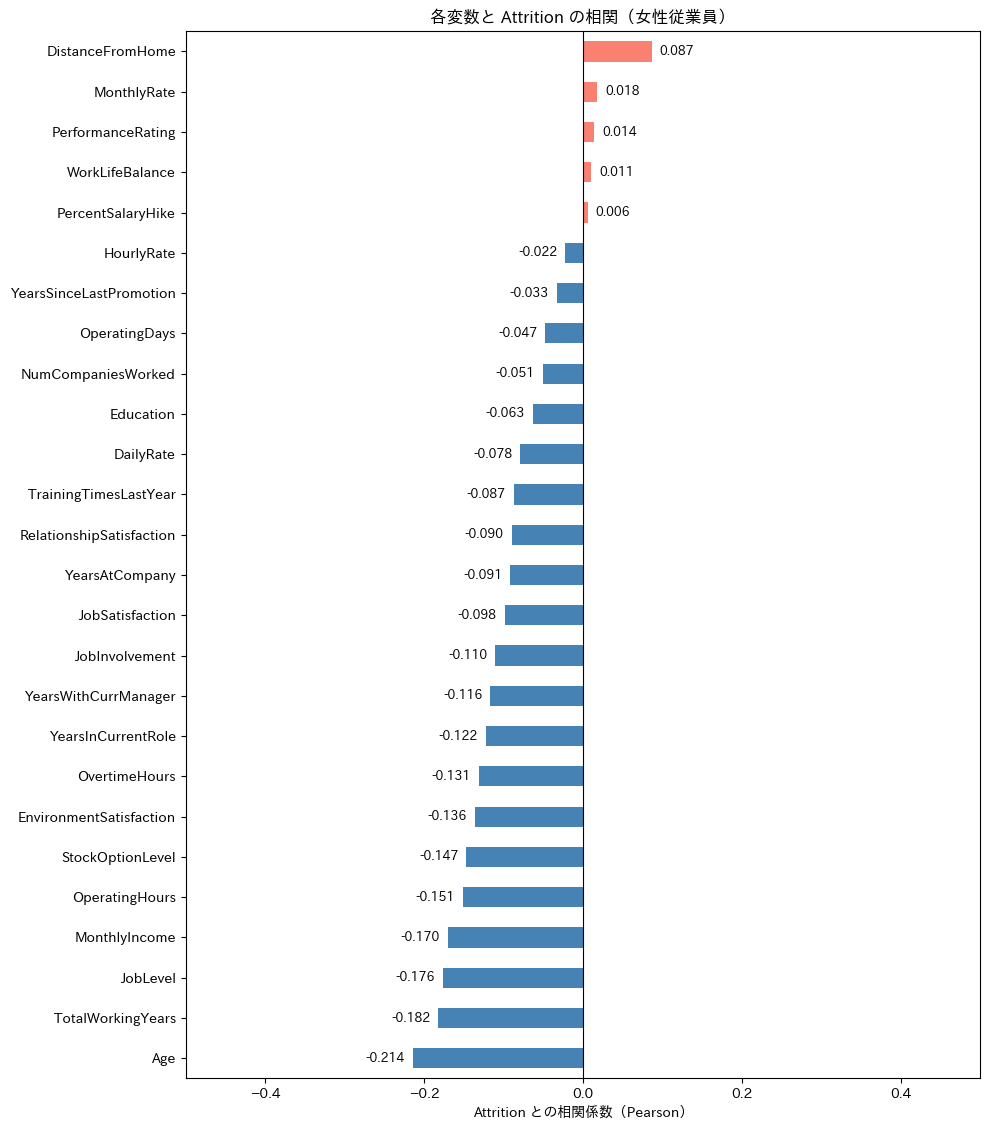

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Attritionとの相関係数を計算
corr = df_female[numeric_cols].corrwith(df_female['Attrition']).sort_values()

# 水平棒グラフで可視化
fig, ax = plt.subplots(figsize=(10, len(numeric_cols) * 0.4 + 1))

colors = ['salmon' if v > 0 else 'steelblue' for v in corr]
corr.plot(kind='barh', ax=ax, color=colors)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Attrition との相関係数（Pearson）')
ax.set_title('各変数と Attrition の相関（女性従業員）')
ax.set_xlim(-0.5, 0.5)

for i, (val, name) in enumerate(zip(corr.values, corr.index)):
    ax.text(val + (0.01 if val >= 0 else -0.01), i,
            f'{val:.3f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

In [34]:
# Spearman相関（順序・非線形に強い）
corr_spearman = df_female[numeric_cols].corrwith(df_female['Attrition'], method='spearman').sort_values()

# 上位・下位5変数だけ確認
print("離職と正の相関トップ5:")
print(corr_spearman.tail(5))
print("\n離職と負の相関トップ5:")
print(corr_spearman.head(5))

離職と正の相関トップ5:
PercentSalaryHike    0.003776
PerformanceRating    0.014270
MonthlyRate          0.018145
WorkLifeBalance      0.019633
DistanceFromHome     0.097243
dtype: float64

離職と負の相関トップ5:
Age                 -0.224284
TotalWorkingYears   -0.221344
MonthlyIncome       -0.217072
JobLevel            -0.204305
StockOptionLevel    -0.182772
dtype: float64


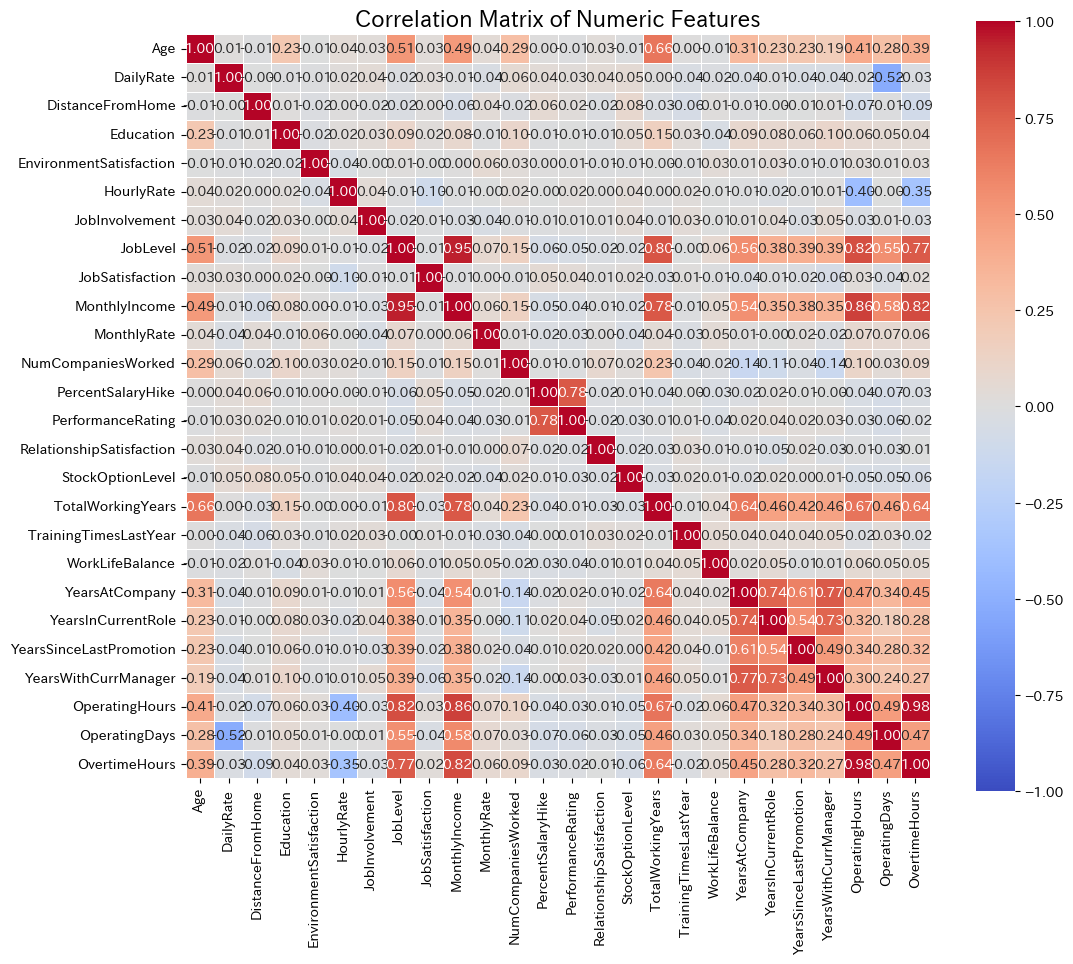

In [35]:
# 数値列の相関行列
df_male_numeric = df_male.select_dtypes(include=['number']).drop(columns=['Gender', 'Attrition'])

plt.figure(figsize=(12, 10))
sns.heatmap(df_male_numeric.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features', fontsize=16)
plt.show()

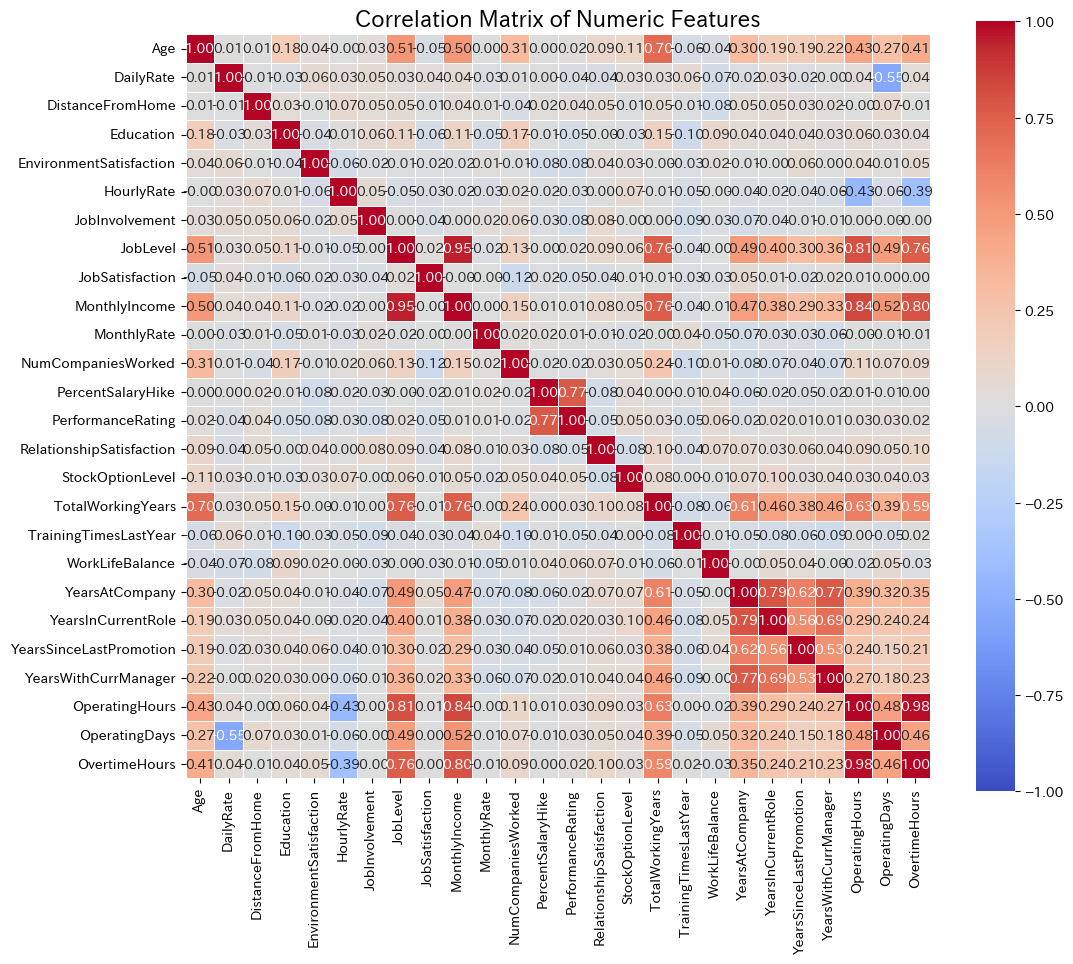

In [36]:
# 数値列の相関行列
df_female_numeric = df_female.select_dtypes(include=['number']).drop(columns=['Gender', 'Attrition'])

plt.figure(figsize=(12, 10))
sns.heatmap(df_female_numeric.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features', fontsize=16)
plt.show()

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler

X = df_male[numeric_cols].fillna(df_male[numeric_cols].median())
y = df_male['Attrition']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LogisticRegression(max_iter=1000)
model.fit(X_scaled, y)

# 各変数の影響度（係数の絶対値）
importance_male = pd.Series(np.abs(model.coef_[0]), index=numeric_cols).sort_values(ascending=False)
print(importance_male)

OvertimeHours               0.980207
OperatingHours              0.952321
YearsSinceLastPromotion     0.604975
NumCompaniesWorked          0.473867
StockOptionLevel            0.439017
YearsWithCurrManager        0.409538
YearsInCurrentRole          0.394503
JobInvolvement              0.382219
TotalWorkingYears           0.365076
JobSatisfaction             0.353905
PercentSalaryHike           0.279903
DistanceFromHome            0.278172
EnvironmentSatisfaction     0.261953
WorkLifeBalance             0.261676
PerformanceRating           0.195708
Age                         0.182927
RelationshipSatisfaction    0.161152
JobLevel                    0.157203
OperatingDays               0.152209
DailyRate                   0.134218
Education                   0.111559
YearsAtCompany              0.109253
MonthlyIncome               0.084680
TrainingTimesLastYear       0.070144
MonthlyRate                 0.056279
HourlyRate                  0.051406
dtype: float64


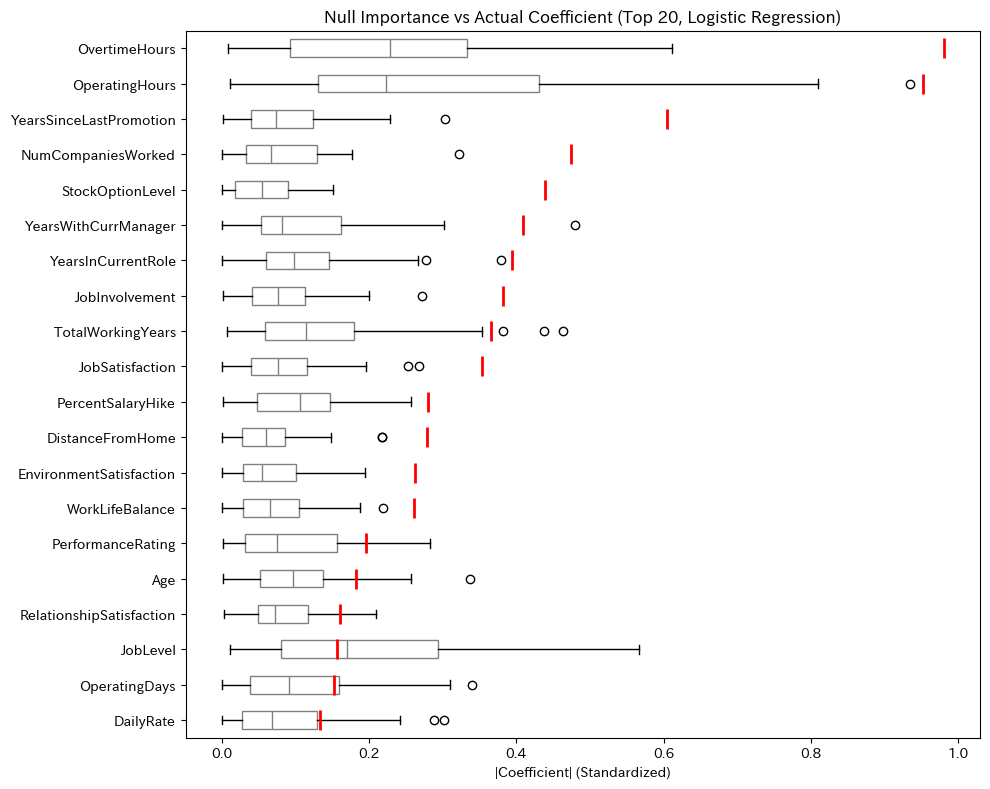

有用な特徴量 (17個): ['Age', 'DistanceFromHome', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobSatisfaction', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'WorkLifeBalance', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'OperatingHours', 'OvertimeHours']
削除候補     (9個): ['DailyRate', 'Education', 'HourlyRate', 'JobLevel', 'MonthlyIncome', 'MonthlyRate', 'TrainingTimesLastYear', 'YearsAtCompany', 'OperatingDays']


In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

X = df_male[numeric_cols].fillna(df_male[numeric_cols].median())
y = df_male['Attrition']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── 本物の係数 ──────────────────────────────────────────
model = LogisticRegression(max_iter=1000)
model.fit(X_scaled, y)
real_coef = pd.Series(np.abs(model.coef_[0]), index=numeric_cols)

# ── Null 係数（y をシャッフルして n_runs 回） ──────────────
n_runs = 50
null_coefs = []
for i in range(n_runs):
    y_shuffled = y.sample(frac=1, random_state=i).reset_index(drop=True)
    m = LogisticRegression(max_iter=1000)
    m.fit(X_scaled, y_shuffled)
    null_coefs.append(np.abs(m.coef_[0]))

null_coef_df = pd.DataFrame(null_coefs, columns=numeric_cols)

# ── Top 20 抽出 ────────────────────────────────────────
top20 = real_coef.sort_values(ascending=False).head(20).index

# ── 描画 ──────────────────────────────────────────────
plt.figure(figsize=(10, 8))
data_to_plot = [null_coef_df[col].values for col in top20[::-1]]

plt.boxplot(
    data_to_plot, vert=False, labels=top20[::-1],
    patch_artist=True,
    boxprops=dict(facecolor='white', color='gray'),
    medianprops=dict(color='gray'),
)

# 実際の係数を赤い縦線で重ねる
for i, col in enumerate(top20[::-1]):
    plt.plot(real_coef[col], i + 1, '|', color='red',
             markersize=15, markeredgewidth=2)

plt.xlabel('|Coefficient| (Standardized)')
plt.title('Null Importance vs Actual Coefficient (Top 20, Logistic Regression)')
plt.tight_layout()
plt.show()

# ── 有用な特徴量の抽出（Null の 80% 超えたら有用） ──────────
scores = {col: (null_coef_df[col] < real_coef[col]).mean() for col in numeric_cols}
useful_features = [col for col, s in scores.items() if s >= 0.8]
drop_cols      = [col for col in numeric_cols if col not in useful_features]

print(f'有用な特徴量 ({len(useful_features)}個): {useful_features}')
print(f'削除候補     ({len(drop_cols)}個): {drop_cols}')

In [ ]:
X2 = df_female[numeric_cols].fillna(df_female[numeric_cols].median())
y2 = df_female['Attrition']

scaler = StandardScaler()
X2_scaled = scaler.fit_transform(X2)

model = LogisticRegression(max_iter=1000)
model.fit(X2_scaled, y2)

# 各変数の影響度（係数の絶対値）
importance_female = pd.Series(np.abs(model.coef_[0]), index=numeric_cols).sort_values(ascending=False)
print(importance_female)

In [ ]:
#女性
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

X = df_female[numeric_cols].fillna(df_female[numeric_cols].median())
y = df_female['Attrition']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── 本物の係数 ──────────────────────────────────────────
model = LogisticRegression(max_iter=1000)
model.fit(X_scaled, y)
real_coef = pd.Series(np.abs(model.coef_[0]), index=numeric_cols)

# ── Null 係数（y をシャッフルして n_runs 回） ──────────────
n_runs = 50
null_coefs = []
for i in range(n_runs):
    y_shuffled = y.sample(frac=1, random_state=i).reset_index(drop=True)
    m = LogisticRegression(max_iter=1000)
    m.fit(X_scaled, y_shuffled)
    null_coefs.append(np.abs(m.coef_[0]))

null_coef_df = pd.DataFrame(null_coefs, columns=numeric_cols)

# ── Top 20 抽出 ────────────────────────────────────────
top20 = real_coef.sort_values(ascending=False).head(20).index

# ── 描画 ──────────────────────────────────────────────
plt.figure(figsize=(10, 8))
data_to_plot = [null_coef_df[col].values for col in top20[::-1]]

plt.boxplot(
    data_to_plot, vert=False, labels=top20[::-1],
    patch_artist=True,
    boxprops=dict(facecolor='white', color='gray'),
    medianprops=dict(color='gray'),
)

# 実際の係数を赤い縦線で重ねる
for i, col in enumerate(top20[::-1]):
    plt.plot(real_coef[col], i + 1, '|', color='red',
             markersize=15, markeredgewidth=2)

plt.xlabel('|Coefficient| (Standardized)')
plt.title('Null Importance vs Actual Coefficient (Top 20, Logistic Regression)')
plt.tight_layout()
plt.show()

# ── 有用な特徴量の抽出（Null の 80% 超えたら有用） ──────────
scores = {col: (null_coef_df[col] < real_coef[col]).mean() for col in numeric_cols}
useful_features = [col for col, s in scores.items() if s >= 0.8]
drop_cols      = [col for col in numeric_cols if col not in useful_features]

print(f'有用な特徴量 ({len(useful_features)}個): {useful_features}')
print(f'削除候補     ({len(drop_cols)}個): {drop_cols}')

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

for label, X_scaled, y in [('男性', X_scaled, y), ('女性', X2_scaled, y2)]:
    model = LogisticRegression(max_iter=1000)
    model.fit(X_scaled, y)

    y_pred = model.predict(X_scaled)
    y_prob = model.predict_proba(X_scaled)[:, 1]

    print(f'=== {label} ===')
    print(f'Accuracy : {accuracy_score(y, y_pred):.3f}')
    print(f'AUC      : {roc_auc_score(y, y_prob):.3f}')
    print(classification_report(y, y_pred, target_names=['在籍', '離職']))
    print()

In [ ]:
from sklearn.model_selection import cross_val_score

for label, X_s, y_ in [('男性', X_scaled, y), ('女性', X2_scaled, y2)]:
    auc_scores = cross_val_score(
        LogisticRegression(max_iter=1000), X_s, y_,
        cv=5, scoring='roc_auc'
    )
    print(f'{label} AUC（5-fold CV）: {auc_scores.mean():.3f} ± {auc_scores.std():.3f}')

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import cross_val_predict
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (label, X_s, y_) in zip(axes, [('男性', X_scaled, y), ('女性', X2_scaled, y2)]):
    model = LogisticRegression(max_iter=1000)

    # 交差検証で予測確率を取得
    y_prob = cross_val_predict(model, X_s, y_, cv=5, method='predict_proba')[:, 1]

    fpr, tpr, _ = roc_curve(y_, y_prob)
    roc_auc = auc(fpr, tpr)

    ax.plot(fpr, tpr, color='steelblue' if label == '男性' else 'salmon',
            lw=2, label=f'AUC = {roc_auc:.3f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax.fill_between(fpr, tpr, alpha=0.1, color='steelblue' if label == '男性' else 'salmon')

    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title(f'ROC曲線（{label}）', fontsize=13)
    ax.legend(loc='lower right', fontsize=11)
    ax.grid(alpha=0.3)

plt.suptitle('離職予測モデル ROC曲線（5-fold CV）', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ============================
# 6. モデリング：ランダムフォレスト（男女別）
# ============================
param_grid = {'max_depth': [3, 5, 7], 'min_samples_leaf': [1, 5, 20]}

for label, df_g in [('男性', df_male), ('女性', df_female)]:
    print(f"\n{'='*50}")
    print(f"  {label}")
    print(f"{'='*50}")

    X = df_g.drop('Attrition', axis=1)
    y = df_g['Attrition']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)

    ## 6-1. ベースライン
    print('\n--- ベースライン ---')
    rfc = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=1,
                                  random_state=42, n_jobs=-1)
    rfc.fit(X_train, y_train)
    print(f'Train AUC: {roc_auc_score(y_train, rfc.predict_proba(X_train)[:, 1]):.4f}')
    print(f'Valid AUC: {roc_auc_score(y_test,  rfc.predict_proba(X_test)[:, 1]):.4f}')

    ## 6-2. ハイパーパラメータ探索（グリッドサーチ）
    print('\n--- グリッドサーチ ---')
    for max_depth in param_grid['max_depth']:
        for min_samples_leaf in param_grid['min_samples_leaf']:
            rfc_g = RandomForestClassifier(max_depth=max_depth, min_samples_leaf=min_samples_leaf,
                                           n_estimators=100, n_jobs=-1, random_state=42)
            rfc_g.fit(X_train, y_train)
            print(f'max_depth={max_depth}, min_samples_leaf={min_samples_leaf} | '
                  f'Train={roc_auc_score(y_train, rfc_g.predict_proba(X_train)[:, 1]):.4f}, '
                  f'Valid={roc_auc_score(y_test, rfc_g.predict_proba(X_test)[:, 1]):.4f}')

    ## 6-3. 最良パラメータで CV 評価
    print('\n--- CV 評価（最良パラメータ） ---')
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    rfc_cv = RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_leaf=5,
                                     random_state=42, n_jobs=-1)
    cv_scores = cross_val_score(rfc_cv, X, y, cv=skf, scoring='roc_auc')
    print(f'CV AUC Scores: {np.round(cv_scores, 4)}')
    print(f'Mean CV AUC : {cv_scores.mean():.4f}')
